=== 최종 제안 모델 (Gini Index 기반 Tree) 평가 ===
Accuracy : 0.6100
Precision: 0.2509
Recall   : 0.7513
F1-score : 0.3761



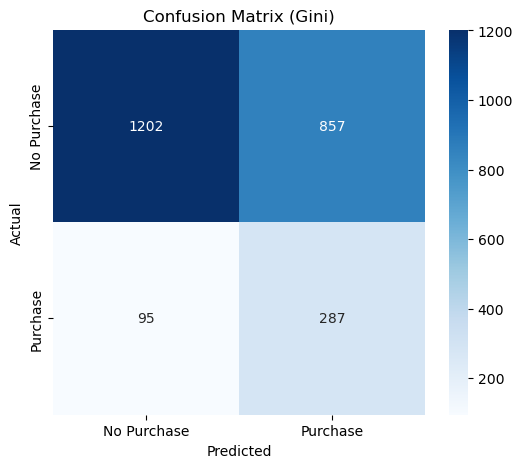

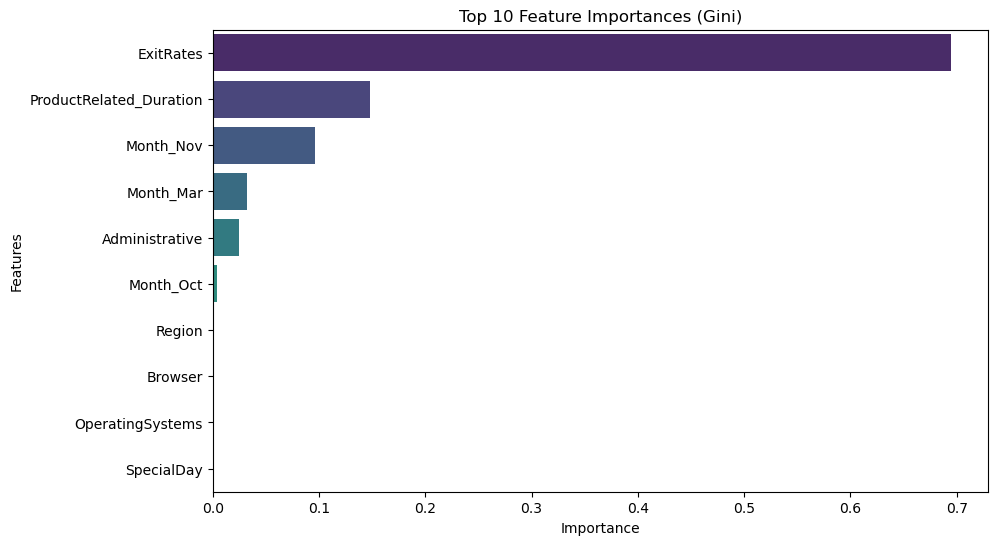

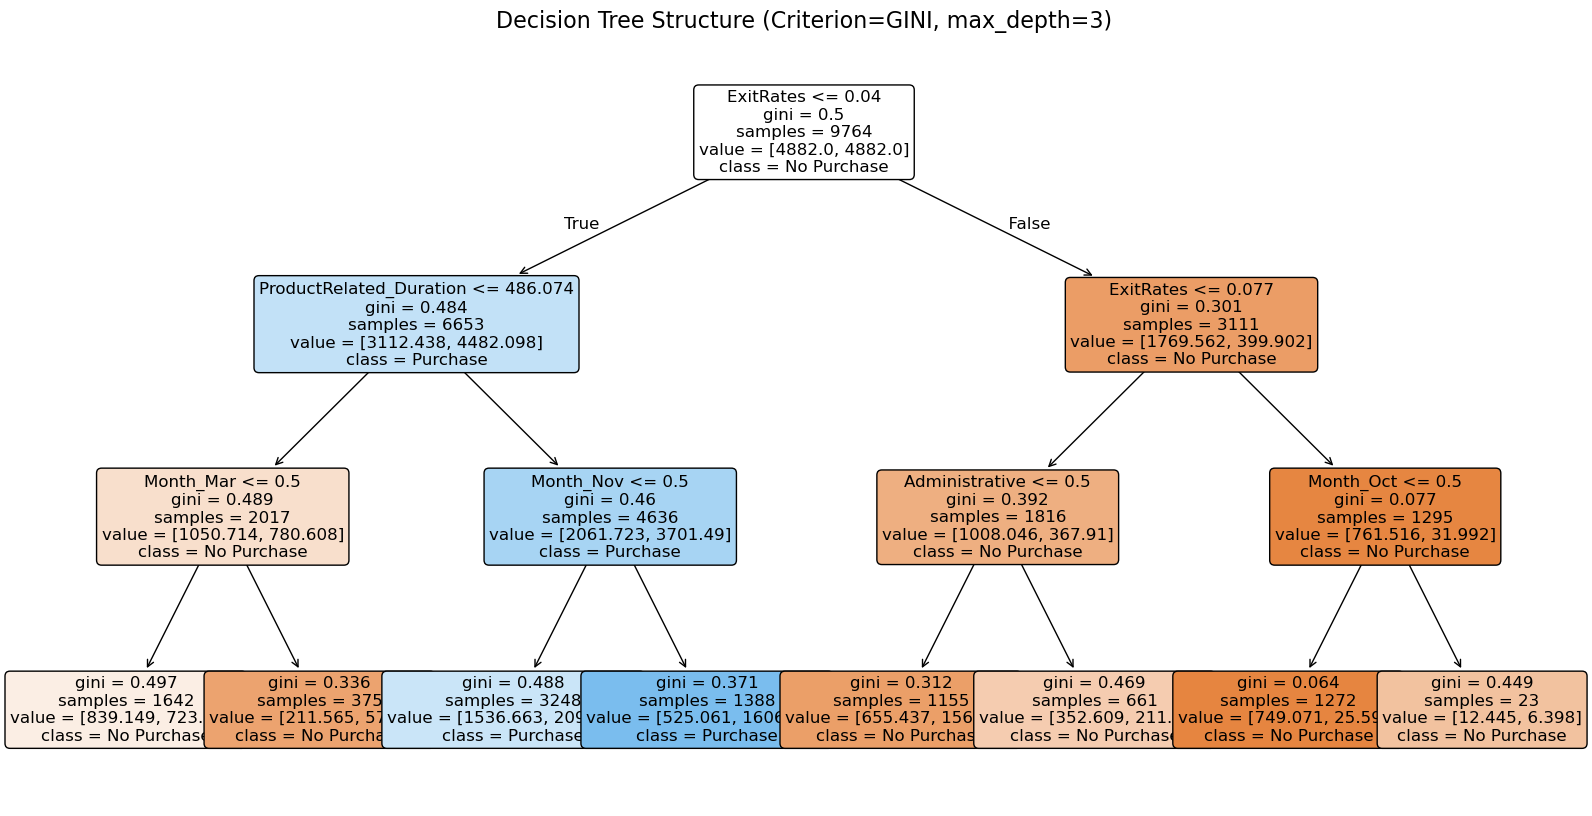


--- Decision Tree Rules ---
|--- ExitRates <= 0.04
|   |--- ProductRelated_Duration <= 486.07
|   |   |--- Month_Mar <= 0.50
|   |   |   |--- class: 0
|   |   |--- Month_Mar >  0.50
|   |   |   |--- class: 0
|   |--- ProductRelated_Duration >  486.07
|   |   |--- Month_Nov <= 0.50
|   |   |   |--- class: 1
|   |   |--- Month_Nov >  0.50
|   |   |   |--- class: 1
|--- ExitRates >  0.04
|   |--- ExitRates <= 0.08
|   |   |--- Administrative <= 0.50
|   |   |   |--- class: 0
|   |   |--- Administrative >  0.50
|   |   |   |--- class: 0
|   |--- ExitRates >  0.08
|   |   |--- Month_Oct <= 0.50
|   |   |   |--- class: 0
|   |   |--- Month_Oct >  0.50
|   |   |   |--- class: 0



In [9]:
import sys
import subprocess

# 필수 라이브러리 체크 및 자동 설치
modules = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'sklearn']
for mod in modules:
    try:
        __import__(mod)
    except ImportError:
        target_mod = 'scikit-learn' if mod == 'sklearn' else mod
        subprocess.check_call([sys.executable, "-m", "pip", "install", target_mod])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 데이터 로드
X_train = pd.read_csv('csv/X_train.csv')
X_test = pd.read_csv('csv/X_test.csv')
y_train = pd.read_csv('csv/y_train.csv').values.ravel()
y_test = pd.read_csv('csv/y_test.csv').values.ravel()

# --------------------------------------------------
# [수업 내용 적용] 지니 불순도(Gini Impurity) 기반 모델 설계
# --------------------------------------------------
# criterion='gini'로 명시 (기본값이지만 보고서 제출용으로 명시적 선언이 좋음)
# max_depth=3 (과적합 방지 사전 가지치기), class_weight='balanced' (불균형 데이터 해소)
model = DecisionTreeClassifier(criterion='gini', max_depth=3, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# 예측 및 평가지표 출력
y_pred = model.predict(X_test)
print("=== 최종 제안 모델 (Gini Index 기반 Tree) 평가 ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}\n")

# Confusion Matrix 시각화 및 저장
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Purchase', 'Purchase'], 
            yticklabels=['No Purchase', 'Purchase'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix (Gini)')
plt.savefig('confusion_matrix_final.png', bbox_inches='tight')
plt.show()

# Feature Importance 시각화 및 저장 (FutureWarning 방지 구조)
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices][:10], y=X_train.columns[indices][:10], hue=X_train.columns[indices][:10], palette='viridis', legend=False)
plt.title('Top 10 Feature Importances (Gini)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.savefig('feature_importance_final.png', bbox_inches='tight')
plt.show()

# 보고서 제출용 트리 구조 시각화 (각 노드별 지니 불순도 감소 확인용)
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=list(X_train.columns), 
          class_names=['No Purchase', 'Purchase'], 
          filled=True, rounded=True, fontsize=12)
plt.title('Decision Tree Structure (Criterion=GINI, max_depth=3)', fontsize=16)
plt.savefig('decision_tree_structure.png', bbox_inches='tight')
plt.show()

# 트리 분기 규칙 출력
print("\n--- Decision Tree Rules ---")
print(export_text(model, feature_names=list(X_train.columns)))